# Hydrology: Water Quality

**Question:** Does water quality change as a stream flows past a developed area?

Reference notebook for The Pond. All observations and locations are **synthetic**, created for this activity; results are not evidence about a real site.

## Preamble: From sketch to notebook

In a previous [LiLyPad](https://linked.earth/ThePond/lilypads/workflow/sketching-workflows/index.html), you sketched a workflow to answer:

**Does water quality change as a stream flows past a developed area?**

In this notebook, we will translate that sketch into a computational workflow. As you work through each section, notice:

- What data does the step receive?
- What operation does it perform?
- What parameters or decisions control that operation?
- What does it produce, and which step uses that output?

An output does not need to be saved as a separate file. It can be a table or another object held in memory; it does not necessarily need its own file, provided we explain what it contains and how it is used.

Follow each input → analysis → output connection in your sketch. Markdown explains meaning and choices as well as describe manual steps; code performs the operation; displayed tables and figures let us inspect the result.


<div class="alert alert-block alert-info">
    <b>Note:</b> A notebook’s preamble introduces the scientific questions it addresses and explains how its analyses fit into the broader study. It is also a useful place to document data sources and software dependencies, including their versions.
</div>

## Exploratory Data Analysis

Let's first load our data and understand how it is organized. 

One row is one nitrate measurement. `station` and `date` identify a sample; `nitrate` uses the row's `unit` (mg/L or ug/L). `qc_complete`: 1 = completed and accepted, 0 = incomplete. `distance_km` increases downstream. The stream passes through a developed area between 4 and 6 km. Repeated station/date pairs are replicate measurements.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

raw = pd.read_csv('data/hydrology.csv')
print(f'Input: {len(raw)} rows')
display(raw.head())

Input: 168 rows


,station,date,nitrate,unit,qc_complete,distance_km
0,S1,2022-01-01,2.837274,mg/L,1,0
1,S1,2022-01-01,2.979138,mg/L,1,0
2,S1,2022-02-01,2221.177221,ug/L,1,0
3,S1,2022-03-01,1.778805,mg/L,1,0
4,S1,2022-04-01,2420.971930,ug/L,1,0


The first few rows show that replicate measurements were collected on some dates and that nitrate concentrations were reported in different units.

## Data Pre-Processing

Our first step is to convert all of our nitrate measurements to the same units. We will append the column `nitrate_mg_L` to our data with the converted numbers. 



In [ ]:
standardized = raw.copy()
standardized['nitrate_mg_L'] = standardized['nitrate'] * standardized['unit'].map({'mg/L':1, 'ug/L':.001})
assert standardized['nitrate_mg_L'].notna().all()
display(standardized.head())

,station,date,nitrate,unit,qc_complete,distance_km,nitrate_mg_L
0,S1,2022-01-01,2.837274,mg/L,1,0,2.837274
1,S1,2022-01-01,2.979138,mg/L,1,0,2.979138
2,S1,2022-02-01,2221.177221,ug/L,1,0,2.221177
3,S1,2022-03-01,1.778805,mg/L,1,0,1.778805
4,S1,2022-04-01,2420.971930,ug/L,1,0,2.420972


Our second step is to average measurements collected at the same station on the same date. Because the original team averaged these measurements before applying quality control (QC), we assign a QC flag of 1 to the average only if every measurement contributing to it has a QC flag of 1.

<div class="alert alert-block alert-info">
    <b>Note:</b> We had to make an assumption about how to combine the QC flags because the original description did not specify this. This illustrates why documenting every methodological choice matters. Applying QC before averaging might seem more intuitive, but the original team may have had a reason for using this order. The two approaches can produce different results.
</div>

In [7]:
averaged = standardized.groupby(['station','date'],as_index=False).agg(nitrate_mg_L=('nitrate_mg_L','mean'), qc_complete=('qc_complete','min'), distance_km=('distance_km','first'), replicates=('nitrate_mg_L','size'))
print(f'{len(standardized)} measurements → {len(averaged)} station/date samples')

168 measurements → 144 station/date samples


In [11]:
display(averaged.head())

,station,date,nitrate_mg_L,qc_complete,distance_km,replicates
0,S1,2022-01-01,2.908206,1,0,2
1,S1,2022-02-01,2.221177,1,0,1
2,S1,2022-03-01,1.778805,1,0,1
3,S1,2022-04-01,2.420972,1,0,1
4,S1,2022-05-01,55.000000,1,0,1


The resulting dataset contains one average nitrate concentration per station and date, retaining only samples with completed and accepted quality checks.

Next, let's remove all the samples that did not pass quality control:

In [12]:
quality = averaged.loc[averaged.qc_complete.eq(1)].copy()
print(f'{len(averaged)} → {len(quality)} samples')

144 → 138 samples


We next remove nitrate concentrations greater than 50 mg/L, the upper limit of the measurement method. Values equal to 50 mg/L are retained.

In [13]:
MAX_NITRATE_MG_L = 50
filtered = quality.loc[quality.nitrate_mg_L.le(MAX_NITRATE_MG_L)].copy()
assert filtered.nitrate_mg_L.between(0,50).all()
print(f'{len(quality)} → {len(filtered)} samples')

138 → 132 samples


## Analysis

Calculate the mean concentration at each station. 

In [14]:
station_means = filtered.groupby('station',as_index=False).agg(mean_nitrate_mg_L=('nitrate_mg_L','mean'), n_dates=('date','size'), distance_km=('distance_km','first')).sort_values('distance_km')
print(station_means.to_string(index=False))

station  mean_nitrate_mg_L  n_dates  distance_km
     S1           2.426186       22            0
     S2           2.804365       22            2
     S3           3.174766       22            4
     S4           6.586605       22            6
     S5           7.040156       22            8
     S6           7.522025       22           10


## Visualization

Let's plot the mean concentration vs distance downstream: 


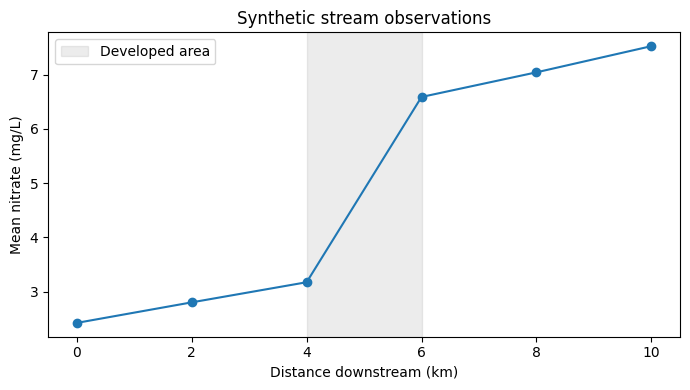

In [15]:
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(station_means.distance_km,station_means.mean_nitrate_mg_L,'o-')
ax.axvspan(4,6,alpha=.15,color='gray',label='Developed area')
ax.set(xlabel='Distance downstream (km)',ylabel='Mean nitrate (mg/L)',title='Synthetic stream observations')
ax.legend(); fig.tight_layout()

The synthetic station means increase downstream of the developed area. This spatial association alone cannot establish its cause but it warrants further investigation. 

If you need help, look at the workflow sketch below:

<details>

<summary><strong>Show the reference workflow</strong></summary>

The reference workflow below shows the data, analysis steps, and parameters used to answer that question.

![Reference workflow for the hydrology scenario](./figures/hydrology-workflow-answer.png)

</details>